In [1]:
import os 

file_dir = "/home/bing_TUM/ehrensberger/master-thesis/imports/mimicgen/datasets/robot"

robots = []
tasks = ["threading_d1"]
depth = False

files = [file for file in os.listdir(file_dir) if all(robot in file for robot in robots) and all(task in file for task in tasks) if ("depth" in file) == depth]
files

['threading_d1_panda.hdf5',
 'threading_d1_iiwa.hdf5',
 'threading_d1_sawyer.hdf5',
 'threading_d1_ur5e.hdf5']

In [2]:
import h5py
from tqdm import tqdm 
from random import randint 

frames = {}
for file in tqdm(files): 
    with h5py.File(os.path.join(file_dir, file), "r") as hf: 
        data = hf["data"]
        
        idx_demo = randint(0, len(data.keys())-1)
        
        demo = data[f"demo_{idx_demo}"]
        n_steps = demo["actions"][()].shape[0]
        
        idx_obs = randint(0, n_steps-1)
        obs = demo["obs"]["robot0_eye_in_hand_image"][idx_obs, ...]
                
    name_robot = file.split(".")[0].split("_")[-1]
    frames[name_robot] = (file, obs, idx_demo, idx_obs)
                
frames.keys()

100%|██████████| 4/4 [00:24<00:00,  6.07s/it]


dict_keys(['panda', 'iiwa', 'sawyer', 'ur5e'])

In [3]:
for key, value in frames.items(): 
    file, _, idx_demo, idx_obs = value
    
    with h5py.File(os.path.join(file_dir, file), "r") as hf: 
        data = hf["data"]
        obs = data[f"demo_{idx_demo}"]["obs"]["robot0_gripper_qpos"][idx_obs, :]
        
        print(f"Gripper state for robot {key}: {obs}")
        
        

Gripper state for robot panda: [ 0.03963    -0.03945928]
Gripper state for robot iiwa: [ 0.47230286 -0.42061326  0.29398384  0.47225211 -0.42105704  0.29423685]
Gripper state for robot sawyer: [-0.00516142  0.00492516]
Gripper state for robot ur5e: [ 0.47239629 -0.4211725   0.29405437  0.4726326  -0.42197827  0.29453854]


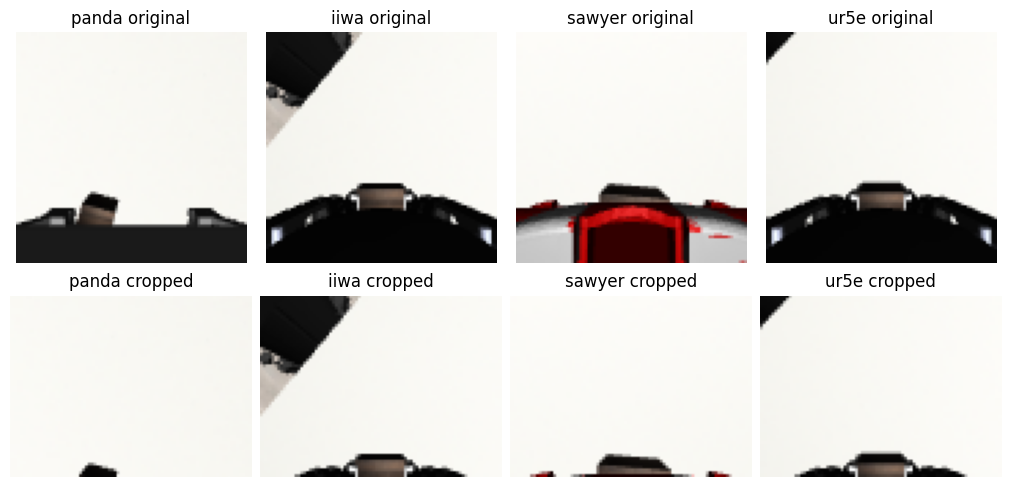

In [4]:
from matplotlib import pyplot as plt 

factor = 0.75
fig, ax = plt.subplots(nrows=2, ncols=len(frames.keys()), figsize=(10, 5), constrained_layout=True)

for i, (key, value) in enumerate(frames.items()):    
    value = value[1]
    # Top Row: Original Images
    ax[0, i].imshow(value)
    ax[0, i].axis("off")
    ax[0, i].set_title(key+" original")
    
    # Bottom Row: Cropped Images
    h = value.shape[0]
    crop_value = value[:int(h*factor), ...]
    ax[1, i].imshow(crop_value)
    ax[1, i].axis("off")
    ax[1, i].set_title(key+" cropped")

plt.savefig("cropped_obs.jpg")
plt.show()